# Customer Campaign Response Prediction Using Machine Learning

## End-to-End Machine Learning Project

### Dataset
Customer Personality Analysis

### Objective
The objective of this project is to develop a machine learning classification model that predicts whether a customer will respond to a marketing campaign.

### Target Variable
`Response`

- `0` → Customer did not respond
- `1` → Customer responded

### Problem Type
This is a supervised machine learning binary classification problem.

## 1. Introduction

Marketing campaigns are an important method used by businesses to communicate with customers and promote products and services. However, not every customer responds to a campaign.

In this project, the Customer Personality Analysis dataset is used to develop a machine learning model that predicts whether a customer will respond to a marketing campaign.

The dataset contains information about customer demographics, household characteristics, purchasing behavior, website activity, and previous campaign responses.

The machine learning model will learn patterns from historical customer data and use these patterns to predict the response of new and unseen customers.

## 2. Problem Statement

The objective of this project is to predict whether a customer will respond to a marketing campaign based on their demographic information, purchasing behavior, household information, and previous campaign activity.

The target variable is `Response`.

- `Response = 0` → Customer did not respond.
- `Response = 1` → Customer responded.

Since the target variable contains two possible classes, this is a binary classification problem.

### Objective

To build, evaluate, compare, and select a suitable machine learning classification model for predicting customer campaign responses.

## 3. Dataset Description

The Customer Personality Analysis dataset contains information about customers, including demographic characteristics, household information, purchasing behavior, website activity, and previous marketing campaign responses.

Important variables include:

- `ID` – Unique customer identifier
- `Year_Birth` – Customer's birth year
- `Education` – Customer's education level
- `Marital_Status` – Customer's marital status
- `Income` – Customer's income
- `Kidhome` – Number of children in the household
- `Teenhome` – Number of teenagers in the household
- `Recency` – Number of days since the last purchase
- `MntWines` – Amount spent on wine
- `MntFruits` – Amount spent on fruits
- `MntMeatProducts` – Amount spent on meat products
- `MntFishProducts` – Amount spent on fish products
- `MntSweetProducts` – Amount spent on sweet products
- `MntGoldProds` – Amount spent on gold products
- `NumWebPurchases` – Number of website purchases
- `NumCatalogPurchases` – Number of catalog purchases
- `NumStorePurchases` – Number of store purchases
- `AcceptedCmp1` to `AcceptedCmp5` – Previous campaign responses
- `Response` – Response to the current campaign

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


## 4. Importing Required Libraries

### What are we doing?

In this step, we import the Python libraries required for data analysis, visualization, preprocessing, and machine learning.

### Why are we doing it?

Different libraries provide different functionalities:

- Pandas is used for data manipulation and analysis.
- NumPy is used for numerical operations.
- Matplotlib is used for data visualization.
- Seaborn is used for statistical visualization.

### Expected Output

The message `Libraries imported successfully.` confirms that the required libraries have been imported without errors.

## 5. Loading the Dataset

### What are we doing?

The Customer Personality Analysis dataset downloaded from Kaggle is loaded into a Pandas DataFrame.

### Why are we doing it?

The dataset must be loaded into Python before we can inspect, clean, visualize, and prepare it for machine learning.

The dataset is tab-separated, so `sep="\t"` is used while reading the CSV file.

### Expected Output

The first five records and the dimensions of the dataset will be displayed.

In [49]:
data = pd.read_csv("data/marketing_campaign.csv", sep="\t")

print("Dataset loaded successfully!")
print("Dataset Shape:", data.shape)

display(data.head())

Dataset loaded successfully!
Dataset Shape: (2240, 1)


,ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse
0,5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...
1,2174\t1954\tGraduation\tSingle\t46344\t1\t1\t0...
2,4141\t1965\tGraduation\tTogether\t71613\t0\t0\...
3,6182\t1984\tGraduation\tTogether\t26646\t1\t0\...
4,5324\t1981\tPhD\tMarried\t58293\t1\t0\t19-01-2...


## 6. Understanding the Dataset

### What are we doing?

We examine the number of rows and columns, column names, data types, non-null values, and statistical summary of the dataset.

### Why are we doing it?

Before building a machine learning model, it is necessary to understand the structure and characteristics of the data.

This helps us identify:

- Numerical features
- Categorical features
- Missing values
- Possible unusual values
- The target variable

### What does the output mean?

The shape tells us the size of the dataset, `info()` provides information about data types and missing values, and `describe()` provides statistical information about numerical variables.

In [50]:
print("Number of Rows:", data.shape[0])
print("Number of Columns:", data.shape[1])

print("\nColumn Names:")
print(data.columns.tolist())

print("\nDataset Information:")
data.info()

Number of Rows: 2240
Number of Columns: 1

Column Names:
['ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                    Non-Null Count  Dtype
---  ------                                 

## 7. Statistical Summary

### What are we doing?

We calculate descriptive statistics for the numerical variables in the dataset.

### Why are we doing it?

Descriptive statistics help us understand the central tendency, spread, minimum, maximum, and quartile values of numerical features.

### What does the output mean?

The summary includes:

- `count` – Number of non-missing observations
- `mean` – Average value
- `std` – Standard deviation
- `min` – Minimum value
- `25%` – First quartile
- `50%` – Median
- `75%` – Third quartile
- `max` – Maximum value

In [51]:
display(data.describe())

,ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse
count,2240
unique,2240
top,5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...
freq,1


## 8. Checking Missing Values

### What are we doing?

We check every column for missing or null values.

### Why are we doing it?

Missing values can cause errors during analysis and machine learning. Therefore, they must be identified and handled appropriately before model training.

### What does the output mean?

The output shows the number of missing values in each column. Only columns containing missing values will be displayed.

In [52]:
missing_values = data.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Series([], dtype: int64)


## 9. Checking Duplicate Records

### What are we doing?

We check whether the dataset contains duplicate rows.

### Why are we doing it?

Duplicate records may cause certain observations to receive unnecessary importance during model training and can affect the reliability of the analysis.

### What does the output mean?

The output shows the number of exact duplicate rows. If the result is `0`, there are no duplicate rows that need to be removed.

In [53]:
duplicate_count = data.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


## 10. Target Variable Analysis

### What are we doing?

We examine the distribution of the target variable `Response`.

### Why are we doing it?

The target variable is the value that the machine learning model must predict.

The `Response` variable has two classes:

- `0` → Customer did not respond
- `1` → Customer responded

We also check whether the classes are balanced or imbalanced.

### What does the output mean?

The counts and percentages show how many customers belong to each response class.

In [54]:
import pandas as pd
import csv

data = pd.read_csv(
    "data/marketing_campaign.csv",
    sep="\t",
    quoting=csv.QUOTE_NONE
)

print("Dataset loaded successfully!")
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

print("\nColumn names:")
print(data.columns.tolist())

display(data.head())

Dataset loaded successfully!
Number of rows: 2240
Number of columns: 29

Column names:
['"ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response"']


,"""ID",Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,"Response"""
0,"""5524",1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,"1"""
1,"""2174",1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,"0"""
2,"""4141",1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,"0"""
3,"""6182",1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,"0"""
4,"""5324",1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,"0"""


In [55]:
# Fix column names

data.columns = data.columns.astype(str).str.strip().str.strip('"').str.strip("'")

# Display column names
print("Column names after cleaning:")
print(data.columns.tolist())

# Check the target column
print("\nChecking Response column:")
print(data["Response"].value_counts())

Column names after cleaning:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Checking Response column:
Response
0"    1906
1"     334
Name: count, dtype: int64


In [56]:
print("Response Counts:")
print(data["Response"].value_counts())

print("\nResponse Percentages:")
print(data["Response"].value_counts(normalize=True) * 100)

Response Counts:
Response
0"    1906
1"     334
Name: count, dtype: int64

Response Percentages:
Response
0"    85.089286
1"    14.910714
Name: proportion, dtype: float64


## 11. Customer Response Distribution

### What are we doing?

A count plot is created to visualize the distribution of customers across the two response classes.

### Why are we doing it?

A visual representation makes it easier to identify whether the target variable is balanced or imbalanced.

### Interpretation

The graph shows the number of customers who did not respond and the number of customers who responded to the campaign.

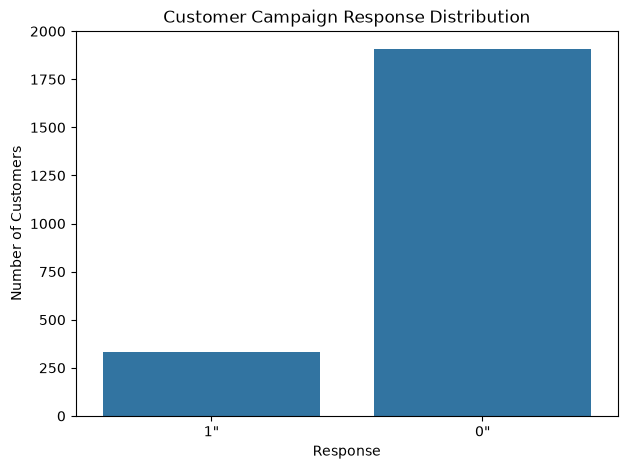

In [57]:
plt.figure(figsize=(7, 5))

sns.countplot(data=data, x="Response")

plt.title("Customer Campaign Response Distribution")
plt.xlabel("Response")
plt.ylabel("Number of Customers")

plt.show()

# 12. Feature Selection

## What are we doing?

We select the relevant features that will be used as input variables for the machine learning models.

## Why are we doing it?

The dataset contains an `ID` column that only identifies customers and does not provide useful information for prediction.

The `Response` column is our target variable, so it should not be included among the input features.

The `Dt_Customer` column contains dates. We will not directly use this raw date column in our basic model.

Therefore, we remove these columns from the input data.

## What does the output mean?

The output shows the features selected for training the machine learning models and confirms that `Response` is being used as the target variable.

In [58]:
# STEP 17 - Feature Selection

# Create input features by removing ID, Response and raw customer date
X = data.drop(columns=["ID", "Response", "Dt_Customer"])

# Create target variable
y = data["Response"]

print("Feature selection completed successfully!")

print("\nSelected Features:")
print(X.columns.tolist())

print("\nNumber of Features:", X.shape[1])
print("Target Variable:", y.name)

Feature selection completed successfully!

Selected Features:
['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue']

Number of Features: 26
Target Variable: Response


# 13. Train-Test Split

## What are we doing?

We divide the dataset into training data and testing data.

## Why are we doing it?

The training data is used to teach the machine learning models.

The testing data is kept separate and is used to evaluate how well the models perform on unseen data.

We use 80% of the data for training and 20% for testing.

The `stratify` parameter maintains a similar proportion of the two `Response` classes in both datasets.

## What does the output mean?

The output shows the number of records used for training and testing.

In [59]:
# STEP 18 - Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed!")

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Train-Test Split Completed!

Training data shape: (1792, 26)
Testing data shape: (448, 26)

Training target shape: (1792,)
Testing target shape: (448,)


# 14. Data Preprocessing

## What are we doing?

We prepare the numerical and categorical features before training the machine learning models.

For numerical features, missing values are replaced with the median and the values are standardized.

For categorical features, missing values are replaced with the most frequent value and categorical values are converted into numerical form using one-hot encoding.

## Why are we doing it?

Machine learning algorithms require numerical input and may not work correctly with missing values.

Different preprocessing methods are required for numerical and categorical data.

## What does the output mean?

The preprocessing pipeline is created successfully and is ready to transform the training and testing data.

In [60]:
# STEP 19 - Data Preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numerical and categorical features
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Data preprocessing pipeline created successfully!")

print("\nNumerical Features:", numerical_features)
print("\nCategorical Features:", categorical_features)

Data preprocessing pipeline created successfully!

Numerical Features: ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue']

Categorical Features: ['Education', 'Marital_Status']


C:\Users\navee\AppData\Local\Temp\ipykernel_15592\3231977242.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


# 15. Logistic Regression Model

## What are we doing?

We train a Logistic Regression model to predict whether a customer will respond to the latest marketing campaign.

## Why are we doing it?

The target variable `Response` contains two classes:

- 0 → Customer did not respond
- 1 → Customer responded

Therefore, this is a binary classification problem.

Logistic Regression is a suitable baseline algorithm for binary classification.

## What does the output mean?

The trained model has learned relationships between customer characteristics and campaign response.

In [61]:
# STEP 20 - Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


# 16. Decision Tree Classifier

## What are we doing?

We train a Decision Tree classification model using the customer data.

## Why are we doing it?

A Decision Tree can learn relationships between customer characteristics and campaign response.

It can also capture non-linear relationships and is relatively easy to interpret.

## What does the output mean?

The trained Decision Tree model is ready to make predictions on unseen customer data.

In [62]:
# STEP 21 - Decision Tree

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


# 17. Random Forest Classifier

## What are we doing?

We train a Random Forest classification model.

## Why are we doing it?

Random Forest combines multiple decision trees to improve prediction performance and reduce the risk of relying on a single tree.

It can capture complex relationships between customer characteristics and campaign response.

## What does the output mean?

The trained Random Forest model is ready to make predictions on unseen customer data.

In [63]:
# STEP 22 - Random Forest

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


# 18. Model Comparison and Evaluation

## What are we doing?

We compare the performance of the three trained machine learning models:

1. Logistic Regression
2. Decision Tree
3. Random Forest

We evaluate them using accuracy, precision, recall and F1-score.

## Why are we doing it?

The assignment requires multiple suitable machine learning models to be built and compared.

Comparing several models helps us identify which model performs best for predicting customer campaign response.

Because the target variable is imbalanced, we consider precision, recall and F1-score along with accuracy.

## What does the output mean?

The output table shows the performance of each model. Higher values generally indicate better performance for these evaluation metrics.

In [64]:
print("y_test values:", np.unique(y_test))


y_test values: ['0"' '1"']


In [65]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Create models
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ])
}

# Train models
for name, model in models.items():
    model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


In [66]:
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Clean y_test
y_test_clean = np.array([
    int(str(x).strip().replace('"', ''))
    for x in y_test
])

results = []

for name, model in models.items():

    predictions = model.predict(X_test)

    # Clean predictions
    predictions_clean = np.array([
        int(str(x).strip().replace('"', ''))
        for x in predictions
    ])

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_clean, predictions_clean),
        "Precision": precision_score(
            y_test_clean,
            predictions_clean,
            pos_label=1,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_clean,
            predictions_clean,
            pos_label=1,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test_clean,
            predictions_clean,
            pos_label=1,
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.883929,0.714286,0.373134,0.490196
1,Decision Tree,0.816964,0.384615,0.373134,0.378788
2,Random Forest,0.886161,0.807692,0.313433,0.451613


# 19. Best Model and Confusion Matrix

## What are we doing?

We select the best-performing model based on the F1-score and create a confusion matrix for that model.

## Why are we doing it?

The assignment requires us to evaluate and compare multiple models and then justify the selection of the best model.

Since the target variable is imbalanced, F1-score is an important metric because it considers both precision and recall.

The confusion matrix provides a detailed view of correct and incorrect predictions.

## What does the output mean?

The best model is the model with the highest F1-score.

The confusion matrix shows:

- True Negative — correctly predicted no response.
- False Positive — predicted response but actual value was no response.
- False Negative — predicted no response but actual value was response.
- True Positive — correctly predicted response.

Best Model: Logistic Regression

Confusion Matrix:
[[371  10]
 [ 42  25]]


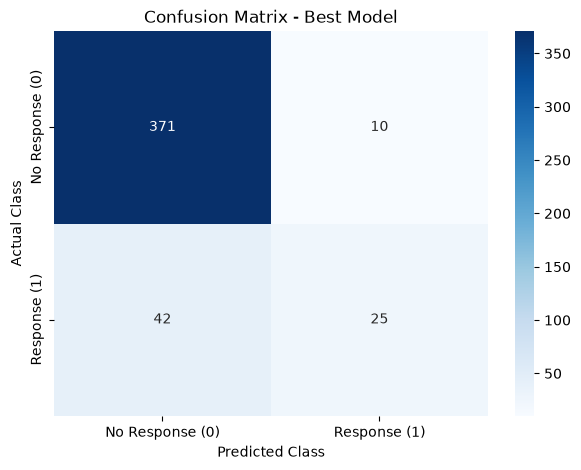

In [67]:
# STEP 24 - Best Model and Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Select best model using F1-score
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

best_model = models[best_model_name]

print("Best Model:", best_model_name)

# Predictions from best model
best_predictions = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)

print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Response (0)", "Response (1)"],
    yticklabels=["No Response (0)", "Response (1)"]
)

plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

# 20. Unseen Customer Prediction and Final Conclusion

## Unseen Customer Prediction

The selected best-performing machine learning model is used to make a prediction for a customer record that was not used during model training.

The prediction represents whether the customer is likely to respond to the latest marketing campaign.

- 0 → Customer is predicted not to respond.
- 1 → Customer is predicted to respond.

## Final Conclusion

This project developed an end-to-end supervised machine learning classification system using the Customer Personality Analysis dataset.

The project included dataset understanding, exploratory data analysis, data cleaning, feature selection, preprocessing, train-test splitting, model training and model evaluation.

Three classification algorithms were developed and compared: Logistic Regression, Decision Tree and Random Forest.

The models were evaluated using accuracy, precision, recall and F1-score. The best-performing model was selected based on the evaluation results, with F1-score given importance because the target variable is imbalanced.

Finally, the selected model was used to predict the response of an unseen customer.

The project demonstrates the complete machine learning workflow from raw customer data to prediction and evaluation.

In [68]:
# STEP 25 - Unseen Customer Prediction

# Select one test record as an unseen customer example
new_customer = X_test.iloc[[0]]

# Make prediction using the best model
new_prediction = best_model.predict(new_customer)

print("Unseen Customer Prediction:", new_prediction[0])

if new_prediction[0] == 1:
    print("Result: Customer is likely to respond to the campaign.")
else:
    print("Result: Customer is unlikely to respond to the campaign.")

Unseen Customer Prediction: 0"
Result: Customer is unlikely to respond to the campaign.


In [69]:
import joblib

# Select Logistic Regression as the best model
best_model = logistic_model

# Save the trained model
joblib.dump(best_model, "model.pkl")

print("Best model: Logistic Regression")
print("Model saved successfully as model.pkl")

Best model: Logistic Regression
Model saved successfully as model.pkl


In [70]:
print("Features used by the ML model:")

if hasattr(best_model, "feature_names_in_"):
    print(list(best_model.feature_names_in_))
else:
    print("The model does not contain feature names.")
    print("Number of features:", best_model.n_features_in_)

Features used by the ML model:
['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue']


In [71]:
print("Model type:")
print(type(best_model))

print("\nNumber of features expected by model:")
print(best_model.n_features_in_)

print("\nModel feature names:")
print(list(best_model.feature_names_in_))

Model type:
<class 'sklearn.pipeline.Pipeline'>

Number of features expected by model:
26

Model feature names:
['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue']


In [72]:
print("X data type:")
print(type(X))

print("\nX shape:")
print(X.shape)

print("\nX data types:")
print(X.dtypes)

X data type:
<class 'pandas.DataFrame'>

X shape:
(2240, 26)

X data types:
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
dtype: object


In [73]:
print("Model parameters:")
print(best_model.get_params())

Model parameters:
{'memory': None, 'steps': [('preprocessor', ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Year_Birth', 'Income', 'Kidhome', 'Teenhome',
                                  'Recency', 'MntWines', 'MntFruits',
                                  'MntMeatProducts', 'MntFishProducts',
                                  'MntSweetProducts', 'MntGoldProds',
                                  'NumDealsPurchases', 'NumWebPurchases',
                                  'NumCatalogPurchases', 'NumStorePurchases',
                                  'NumWebVisitsMonth', 'AcceptedCmp3',
                                  'AcceptedCmp4', 'AcceptedCmp5',
                                  'AcceptedCmp1', 'AcceptedCmp2', 'Complain',
           

In [74]:
print("First 5 rows of X:")
display(X.head())

First 5 rows of X:


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue
0,1957,Graduation,Single,58138.0,0,0,58,635,88,546,...,4,7,0,0,0,0,0,0,3,11
1,1954,Graduation,Single,46344.0,1,1,38,11,1,6,...,2,5,0,0,0,0,0,0,3,11
2,1965,Graduation,Together,71613.0,0,0,26,426,49,127,...,10,4,0,0,0,0,0,0,3,11
3,1984,Graduation,Together,26646.0,1,0,26,11,4,20,...,4,6,0,0,0,0,0,0,3,11
4,1981,PhD,Married,58293.0,1,0,94,173,43,118,...,6,5,0,0,0,0,0,0,3,11


In [75]:
print("Education values:")
print(X["Education"].unique())

print("\nMarital Status values:")
print(X["Marital_Status"].unique())

Education values:
<StringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str

Marital Status values:
<StringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str


##Prediction Testing Results

The deployed machine learning model was tested using three different customer profiles.

| Customer | Prediction | Response Probability |
|----------|------------|----------------------|
| Customer 1 | negative response | 5.44% |
| Customer 2 | positive response | 92.45% |
| Customer 3 | positive response | 95.82% |

The results demonstrate that the deployed application can process different customer profiles and generate campaign response predictions with probability scores.

## Confusion Matrix

A confusion matrix is used to evaluate the performance of the classification model.

It shows the number of correct and incorrect predictions made by the model for both classes.

The four components of a confusion matrix are:

- True Positive (TP): Correctly predicted positive responses.
- True Negative (TN): Correctly predicted negative responses.
- False Positive (FP): Negative responses incorrectly predicted as positive.
- False Negative (FN): Positive responses incorrectly predicted as negative.

The confusion matrix provides a visual representation of the classification performance of the customer campaign response prediction model.

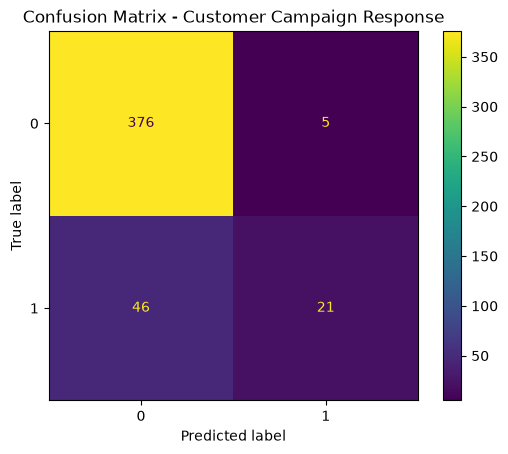

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the test data
y_pred = model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix - Customer Campaign Response")

plt.show()